# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

/home/morrowto/.local/lib/python3.10/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [3]:
df = pd.read_csv('../../data/am_pm.csv')
df.head()

,Unnamed: 0,date,am,pm,target,predict
0,0,2020-04-17,21,2,workday,weekend
1,1,2020-04-18,1,68,weekend,workday
2,2,2020-04-19,18,15,weekend,workday
3,3,2020-04-20,2,23,workday,workday
4,4,2020-04-21,0,25,workday,workday


In [4]:
X, y = df[['am', 'pm']], df['target']
model = LogisticRegression(random_state=21, fit_intercept=False)
model.fit(X,y)

w1, w2 = model.coef_[0]
b = model.intercept_[0]

x_vals = np.linspace(df['am'].min(), df['am'].max(), 100)
y_vals = -(w1 * x_vals + b) / w2  # Solve for y

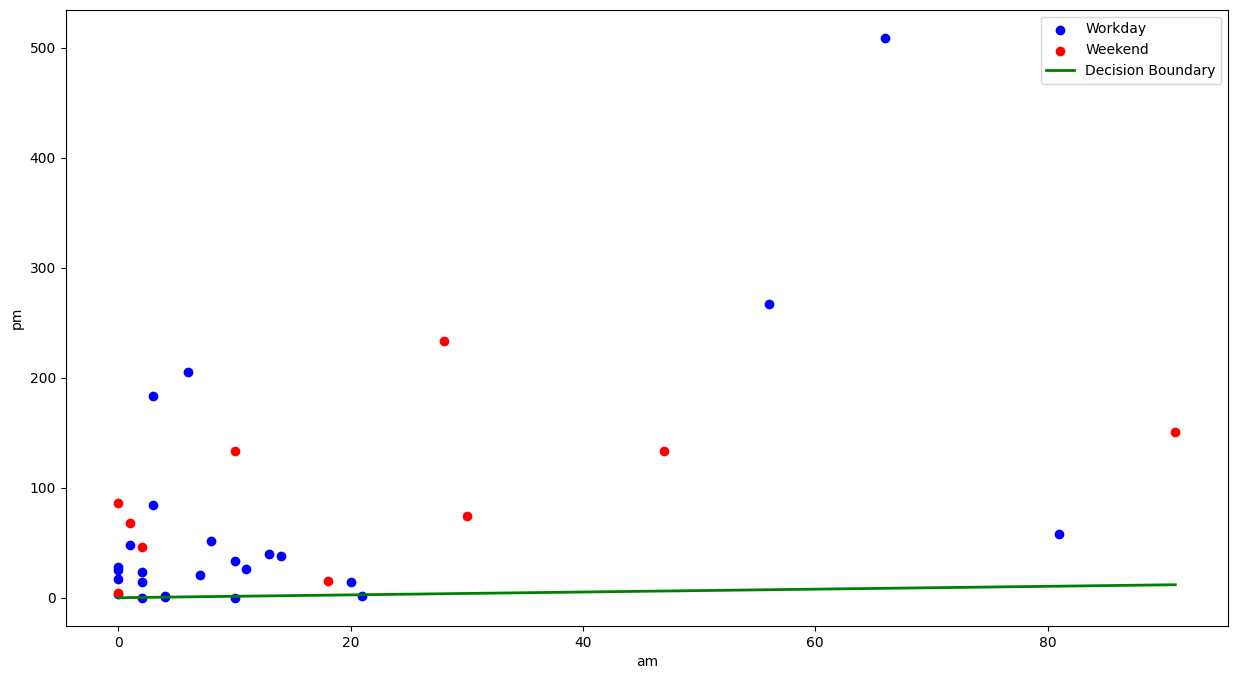

In [5]:
plt.figure(figsize=(15, 8))

workdays = df[df['target'] == 'workday']
plt.scatter(workdays['am'], workdays['pm'], color='blue', label='Workday')

weekends = df[df['target'] == 'weekend']
plt.scatter(weekends['am'], weekends['pm'], color='red', label='Weekend')
plt.plot(x_vals, y_vals, linewidth=2, color = 'green', label="Decision Boundary")

plt.xlabel('am')
plt.ylabel('pm')
plt.legend()

plt.show()

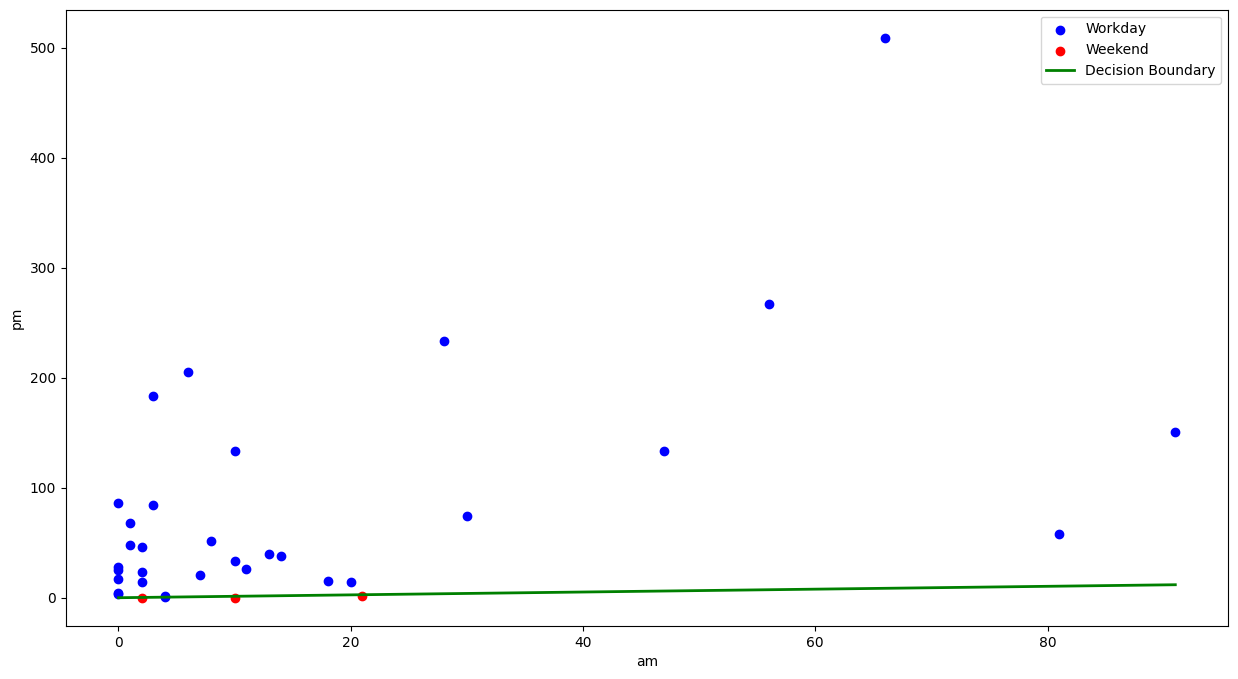

In [6]:
plt.figure(figsize=(15, 8))

workdays = df[df['predict'] == 'workday']
plt.scatter(workdays['am'], workdays['pm'], color='blue', label='Workday')

weekends = df[df['predict'] == 'weekend']
plt.scatter(weekends['am'], weekends['pm'], color='red', label='Weekend')
plt.plot(x_vals, y_vals, linewidth=2, color = 'green', label="Decision Boundary")

plt.xlabel('am')
plt.ylabel('pm')
plt.legend()

plt.show()

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X) 
X = scaler.transform(X)

model = LogisticRegression(random_state=21, fit_intercept=False)
model.fit(X,y)

df['predict after scaling'] = model.predict(X)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(df['target'], df['predict after scaling'])
accuracy

0.7428571428571429

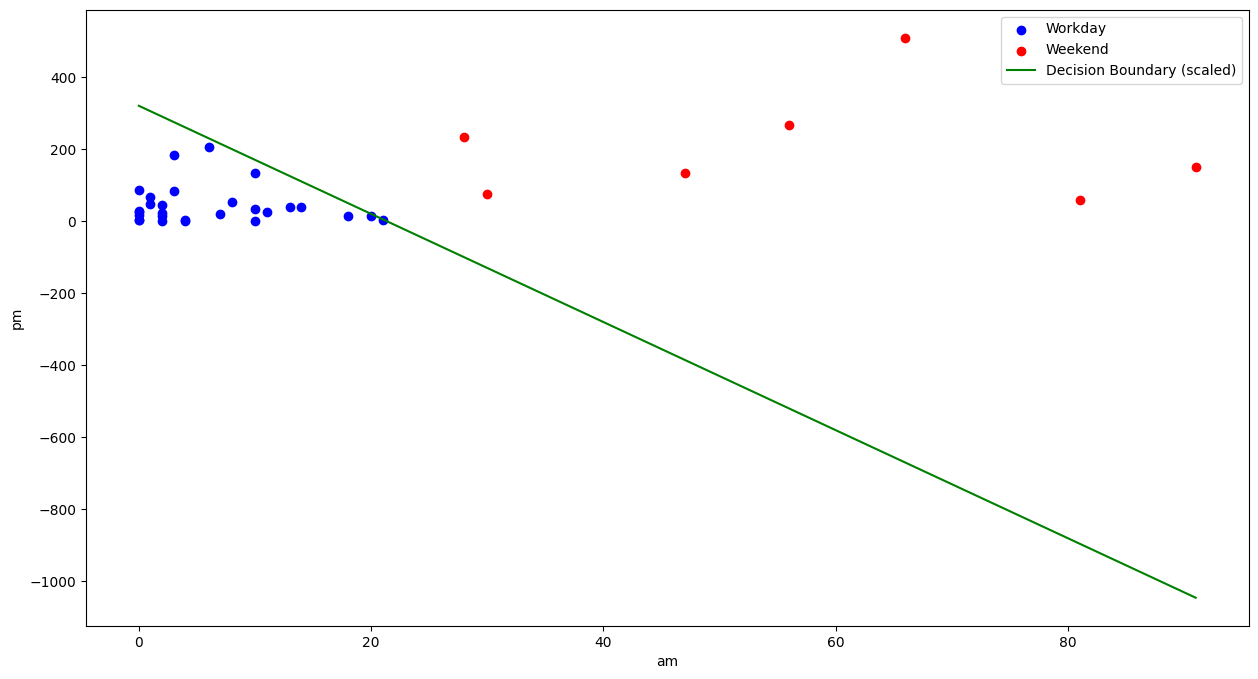

In [8]:
plt.figure(figsize=(15, 8))

workdays = df[df['predict after scaling'] == 'workday']
plt.scatter(workdays['am'], workdays['pm'], color='blue', label='Workday')

weekends = df[df['predict after scaling'] == 'weekend']
plt.scatter(weekends['am'], weekends['pm'], color='red', label='Weekend')

w1, w2 = model.coef_[0]
b = model.intercept_[0]

x_vals_original = np.linspace(df['am'].min(), df['am'].max(), 100)
x_vals_scaled = (x_vals_original - scaler.mean_[0]) / scaler.scale_[0]
y_vals_scaled = -(w1 * x_vals_scaled + b) / w2
y_vals_original = y_vals_scaled * scaler.scale_[1] + scaler.mean_[1]

plt.plot(x_vals_original, y_vals_original, '-', color = 'green', label="Decision Boundary (scaled)")

plt.xlabel('am')
plt.ylabel('pm')
plt.legend()
plt.show()

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [9]:
from sklearn.svm import SVC

kernel_lst = ['linear', 'poly', 'rbf', 'sigmoid']

best_accuracy = 0
best_kernel = None
best_model = None

for kernel_el in kernel_lst:
    model = SVC(probability=True, random_state=21, kernel=kernel_el)
    model.fit(X, y)
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred)
    print(f"{accuracy:.4f} - accuracy of {kernel_el}")
    
    if accuracy >= best_accuracy:
        best_accuracy = accuracy
        best_kernel = kernel_el
        best_model = model

print(f"\nBest kernel: {best_kernel} (Accuracy: {best_accuracy:.4f})")


df['SVM predict'] = best_model.predict(X)
final_accuracy = accuracy_score(y, df['SVM predict'])
print(f"\nFinal accuracy: {final_accuracy: }")

0.7143 - accuracy of linear
0.7429 - accuracy of poly
0.7429 - accuracy of rbf
0.6857 - accuracy of sigmoid

Best kernel: rbf (Accuracy: 0.7429)

Final accuracy:  0.7428571428571429


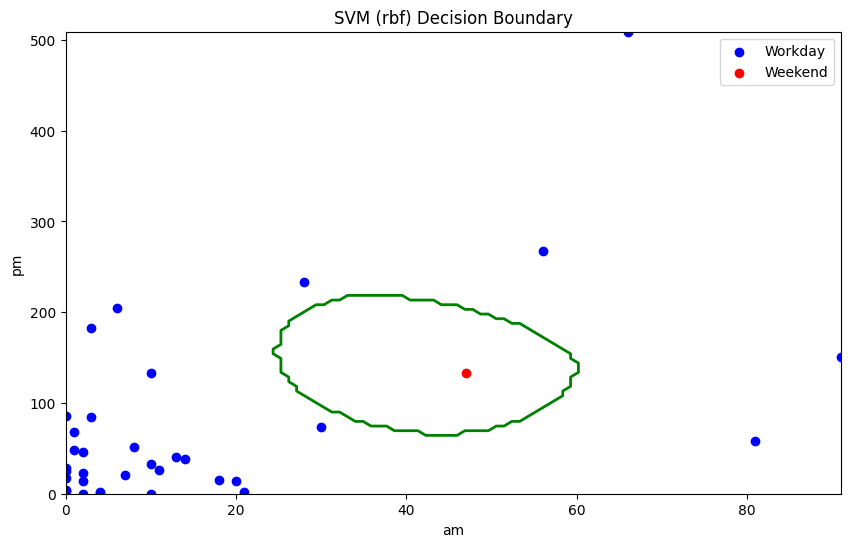

In [10]:
plt.figure(figsize=(10, 6))

workdays = df[df['SVM predict'] == 'workday']
weekends = df[df['SVM predict'] == 'weekend']
plt.scatter(workdays['am'], workdays['pm'], color='blue', label='Workday')
plt.scatter(weekends['am'], weekends['pm'], color='red', label='Weekend')

if best_model.kernel == 'linear':
    w1, w2 = best_model.coef_[0]
    b = best_model.intercept_[0]
    x_vals = np.linspace(df['am'].min(), df['am'].max(), 100)
    y_vals = -(w1 * x_vals + b) / w2
    plt.plot(x_vals, y_vals, 'g-', linewidth=2, label="Decision Boundary")
else:
    # Создаем DataFrame для meshgrid с правильными именами признаков
    xx, yy = np.meshgrid(
        np.linspace(df['am'].min(), df['am'].max(), 100),
        np.linspace(df['pm'].min(), df['pm'].max(), 100)
    )
    mesh_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], 
                             columns=['am', 'pm'])  # Явно указываем имена
    
    mesh_points_scaled = scaler.transform(mesh_points)
    Z = best_model.predict(mesh_points_scaled)

    Z_numeric = np.where(Z == 'weekend', 1, 0).reshape(xx.shape)
    
    plt.contour(xx, yy, Z_numeric, colors='green', linewidths=2, levels=[0.5])

plt.xlabel('am')
plt.ylabel('pm')
plt.title(f'SVM ({best_model.kernel}) Decision Boundary')
plt.legend()
plt.show()

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['target encoded'] = le.fit_transform(df['target'])

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X, df['target encoded'])

df['Tree predict'] = model.predict(X)
accuracy = accuracy_score(df['target encoded'], df['Tree predict'])
accuracy

0.9428571428571428

In [14]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

mesh_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(mesh_points).reshape(xx.shape)

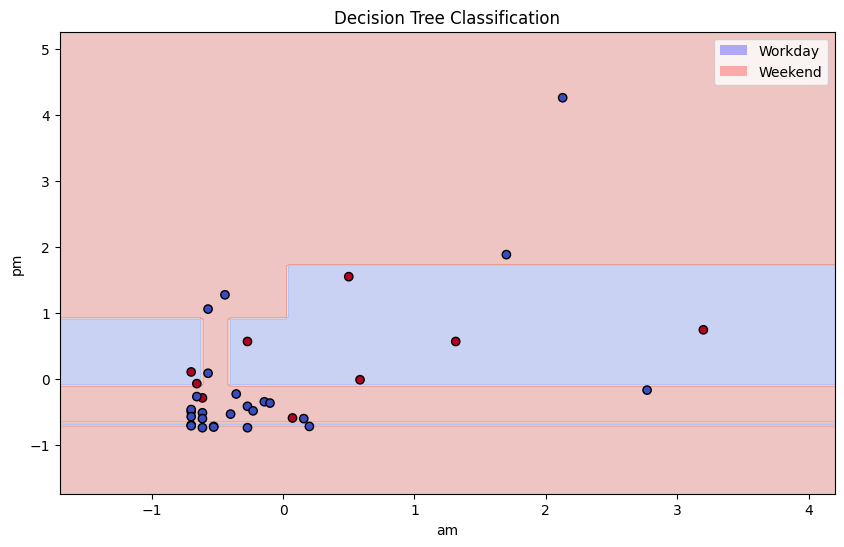

In [22]:
from matplotlib.patches import Patch
plt.figure(figsize=(10, 6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

scatter = plt.scatter(X[:, 0], X[:, 1], c=np.where(y == 'weekend', 1, 0), 
            cmap='coolwarm', edgecolor='k', label=y)

legend_elements = [Patch(facecolor='blue', alpha=0.3, label='Workday'),
                   Patch(facecolor='red', alpha=0.3, label='Weekend')]

plt.legend(handles=legend_elements, loc='upper right')

plt.xlabel('am')
plt.ylabel('pm')
plt.title('Decision Tree Classification')
plt.show()

[Text(0.40625, 0.9, 'y <= -0.121\ngini = 0.408\nsamples = 35\nvalue = [10, 25]\nclass = workday'),
 Text(0.125, 0.7, 'y <= -0.705\ngini = 0.227\nsamples = 23\nvalue = [3, 20]\nclass = workday'),
 Text(0.265625, 0.8, 'True  '),
 Text(0.0625, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]\nclass = workday'),
 Text(0.1875, 0.5, 'y <= -0.651\ngini = 0.291\nsamples = 17\nvalue = [3, 14]\nclass = workday'),
 Text(0.125, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = weekend'),
 Text(0.25, 0.3, 'x <= -0.013\ngini = 0.219\nsamples = 16\nvalue = [2, 14]\nclass = workday'),
 Text(0.1875, 0.1, 'gini = 0.142\nsamples = 13\nvalue = [1, 12]\nclass = workday'),
 Text(0.3125, 0.1, 'gini = 0.444\nsamples = 3\nvalue = [1, 2]\nclass = workday'),
 Text(0.6875, 0.7, 'y <= 0.9\ngini = 0.486\nsamples = 12\nvalue = [7, 5]\nclass = weekend'),
 Text(0.546875, 0.8, '  False'),
 Text(0.5625, 0.5, 'x <= -0.42\ngini = 0.245\nsamples = 7\nvalue = [6, 1]\nclass = weekend'),
 Text(0.5, 0.3, 'x <= -0.613\ngini =

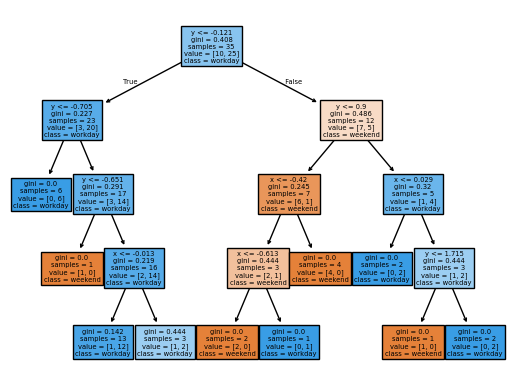

In [25]:
from sklearn.tree import plot_tree

plot_tree(model, feature_names=['x', 'y'], class_names=le.classes_, filled=True)

In [ ]:
n_workday_leaves = sum(1 for i in range(model.tree_.node_count) 
                  if model.tree_.children_left[i] == -1  # Это лист
                  and np.argmax(model.tree_.value[i]) == 0)  # Класс workday (0)

print(f"Количество листьев с рабочими днями: {n_workday_leaves}")

Реальное количество листьев workday: 4
